# $C_3$ on Facebook

This notebook explores the **3rd-order higher-order clustering coefficient** $C_3$ on the Facebook ground-truth graph. This metric is the cleanest “beyond triangles” extension in the current bundle.

## Metric definition

Following Yin, Benson, and Leskovec (2018),

$$C_\ell(G)=\frac{(\ell^2+\ell)|K_{\ell+1}(G)|}{|W_\ell(G)|}. $$

For $\ell=3$,

$$C_3(G)=\frac{12|K_4(G)|}{|W_3(G)|}. $$

Interpretation: start from a triangle-centered higher-order wedge; how often does it close into a 4-clique?

In [3]:

from pathlib import Path
import sys
import math
import itertools
import shutil

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'metrics.py').exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR.parent

sys.path.insert(0, str(NOTEBOOK_DIR))
from metrics import (
    load_graph,
    higher_order_global_clustering,
    higher_order_average_local_clustering,
    higher_order_local_clustering,
    node_k_clique_membership_counts,
)

DATA_PATH = NOTEBOOK_DIR.parent / 'data' / 'gt_txt' / 'facebook.txt'
G = load_graph(DATA_PATH)
print(f'Loaded {DATA_PATH.name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')


Loading graph: 88234it [00:00, 673592.03it/s]


Loaded facebook.txt: 4039 nodes, 88234 edges


In [4]:

def induced_ego_subgraph(G, center=None, radius=1, max_nodes=40):
    if center is None:
        center = max(G.degree, key=lambda x: x[1])[0]
    nodes = set(nx.single_source_shortest_path_length(G, center, cutoff=radius).keys())
    H = G.subgraph(nodes).copy()
    if H.number_of_nodes() > max_nodes:
        nbrs = sorted(H.nodes(), key=lambda u: (-G.degree[u], u))[:max_nodes]
        H = G.subgraph(nbrs).copy()
    return center, H


def edge_df(G):
    return pd.DataFrame(sorted((min(u,v), max(u,v)) for u,v in G.edges()), columns=['u','v'])


In [5]:
c3_global = higher_order_global_clustering(G, 3)
c3_local_avg = higher_order_average_local_clustering(G, 3)
pd.DataFrame([
    {'metric': 'C3 global', 'value': c3_global},
    {'metric': 'C3 average local', 'value': c3_local_avg},
])

Processing nodes: 100%|██████████| 4039/4039 [00:03<00:00, 1124.30it/s]
Enumerating k-cliques: 1612010it [00:03, 445570.90it/s]
Processing nodes: 100%|██████████| 4039/4039 [00:03<00:00, 1071.71it/s]
Enumerating k-cliques: 1612010it [00:03, 424344.29it/s]
Processing nodes: 100%|██████████| 4039/4039 [01:06<00:00, 60.94it/s]  
Enumerating k-cliques: 30004668it [01:06, 452579.78it/s]
Computing higher-order local clustering: 100%|██████████| 4039/4039 [00:00<00:00, 883299.12it/s]


,metric,value
0,C3 global,0.511600
1,C3 average local,0.164854


## Nodewise ingredients

For a node $u$, one convenient formula is

$$C_3(u)=\frac{|K_4(u)|}{(d_u-2)|K_3(u)|}. $$

So we need:
- how many triangles contain the node
- how many 4-cliques contain the node
- the node degree

In [6]:
K3_u = node_k_clique_membership_counts(G, 3)
K4_u = node_k_clique_membership_counts(G, 4)
C3_u = higher_order_local_clustering(G, 3)
node_df = pd.DataFrame({
    'node': sorted(G.nodes()),
    'degree': [G.degree[u] for u in sorted(G.nodes())],
    'K3_memberships': [K3_u[u] for u in sorted(G.nodes())],
    'K4_memberships': [K4_u[u] for u in sorted(G.nodes())],
    'C3_local': [C3_u.get(u, np.nan) for u in sorted(G.nodes())],
}).sort_values('C3_local', ascending=False)
node_df.head(20)

Processing nodes: 100%|██████████| 4039/4039 [00:03<00:00, 1127.67it/s]
Enumerating k-cliques: 1612010it [00:03, 421222.86it/s]
Processing nodes: 100%|██████████| 4039/4039 [01:05<00:00, 61.61it/s]  
Enumerating k-cliques: 30004668it [01:05, 457538.11it/s]
Processing nodes: 100%|██████████| 4039/4039 [00:03<00:00, 1089.59it/s]
Enumerating k-cliques: 1612010it [00:03, 431251.60it/s]
Processing nodes: 100%|██████████| 4039/4039 [01:04<00:00, 62.43it/s] 
Enumerating k-cliques: 30004668it [01:04, 463662.48it/s]
Computing higher-order local clustering: 100%|██████████| 4039/4039 [00:00<00:00, 860419.21it/s]


,node,degree,K3_memberships,K4_memberships,C3_local
39,39,3,3,1,0.333333
11,11,6,15,20,0.333333
114,114,5,10,10,0.333333
2616,2616,3,3,1,0.333333
797,797,4,6,4,0.333333
799,799,3,3,1,0.333333
2624,2624,3,3,1,0.333333
796,796,3,3,1,0.333333
3629,3629,6,15,20,0.333333
815,815,4,6,4,0.333333


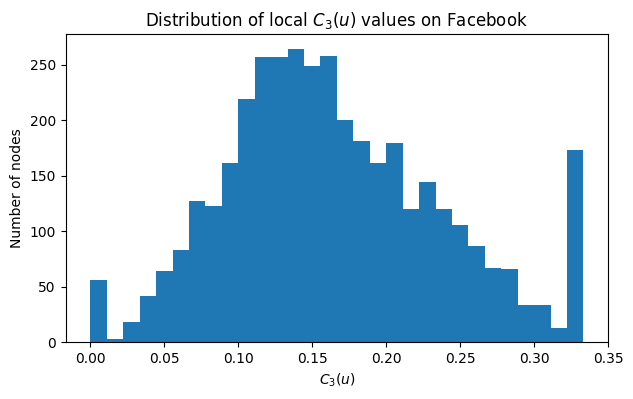

In [7]:
plt.figure(figsize=(7,4))
vals = node_df['C3_local'].dropna()
plt.hist(vals, bins=30)
plt.title('Distribution of local $C_3(u)$ values on Facebook')
plt.xlabel('$C_3(u)$')
plt.ylabel('Number of nodes')
plt.show()

## Example

Pick one node with a high local $C_3$ and verify the numerator and denominator manually.

In [8]:
row = node_df.dropna().iloc[0]
u = int(row['node'])
du = G.degree[u]
num = K4_u[u]
denom = (du - 2) * K3_u[u]
manual = num / denom if denom > 0 else np.nan
pd.DataFrame([
    {'quantity': 'node', 'value': u},
    {'quantity': 'degree d_u', 'value': du},
    {'quantity': '|K3(u)|', 'value': K3_u[u]},
    {'quantity': '|K4(u)|', 'value': K4_u[u]},
    {'quantity': '(d_u - 2) * |K3(u)|', 'value': denom},
    {'quantity': 'manual C3(u)', 'value': manual},
    {'quantity': 'computed C3(u)', 'value': C3_u[u]},
])

,quantity,value
0,node,39.000000
1,degree d_u,3.000000
2,|K3(u)|,3.000000
3,|K4(u)|,1.000000
4,(d_u - 2) * |K3(u)|,3.000000
5,manual C3(u),0.333333
6,computed C3(u),0.333333


## Interpretation

$C_3$ complements 4-clique density:
- 4-clique density asks how common 4-cliques are among all 4-node sets.
- $C_3$ asks how often existing triangle-based structure *expands* into 4-cliques.

For realism testing, matching Facebook's $C_3$ means reproducing its tendency for triangles to sit inside denser 4-node groups.